
 LOADING GOOGLE STOCK DATASET 

 DATASET LOADED SUCCESSFULLY 

First 5 Rows:

  symbol        date       open       high        low      close    volume  \
0   GOOG  2018-01-02  52.417000  53.347000  52.261501  53.250000  24752000   
1   GOOG  2018-01-03  53.215500  54.314499  53.160500  54.124001  28604000   
2   GOOG  2018-01-04  54.400002  54.678501  54.200100  54.320000  20092000   
3   GOOG  2018-01-05  54.700001  55.212502  54.599998  55.111500  25582000   
4   GOOG  2018-01-08  55.111500  55.563499  55.081001  55.347000  20952000   

    adjclose  dividends  splits  
0  53.059353        0.0     0.0  
1  53.930225        0.0     0.0  
2  54.125519        0.0     0.0  
3  54.914188        0.0     0.0  
4  55.148846        0.0     0.0  

 DATASET COLUMNS 
Index(['symbol', 'date', 'open', 'high', 'low', 'close', 'volume', 'adjclose',
       'dividends', 'splits'],
      dtype='object')

Selected Stock Column : open

Dataset Shape : (1761, 1)

Feature Scaling Completed

 TIME SERIES

C:\Users\sapiyan\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


43/43 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step - loss: 0.0284
Epoch 2/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 0.0027
Epoch 3/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 0.0029
Epoch 4/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 0.0022
Epoch 5/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 0.0020
Epoch 6/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 0.0019
Epoch 7/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 0.0021
Epoch 8/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 0.0021
Epoch 9/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 0.0018
Epoch 10/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 0.0022
Epoch 11/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 0.0016
Epoch 12/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 0.0017
Epoch 13/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 0.0015
Epoch 14/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - loss: 0.0016
Epoch 15/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 0.0016
Epoch 16/30
43/

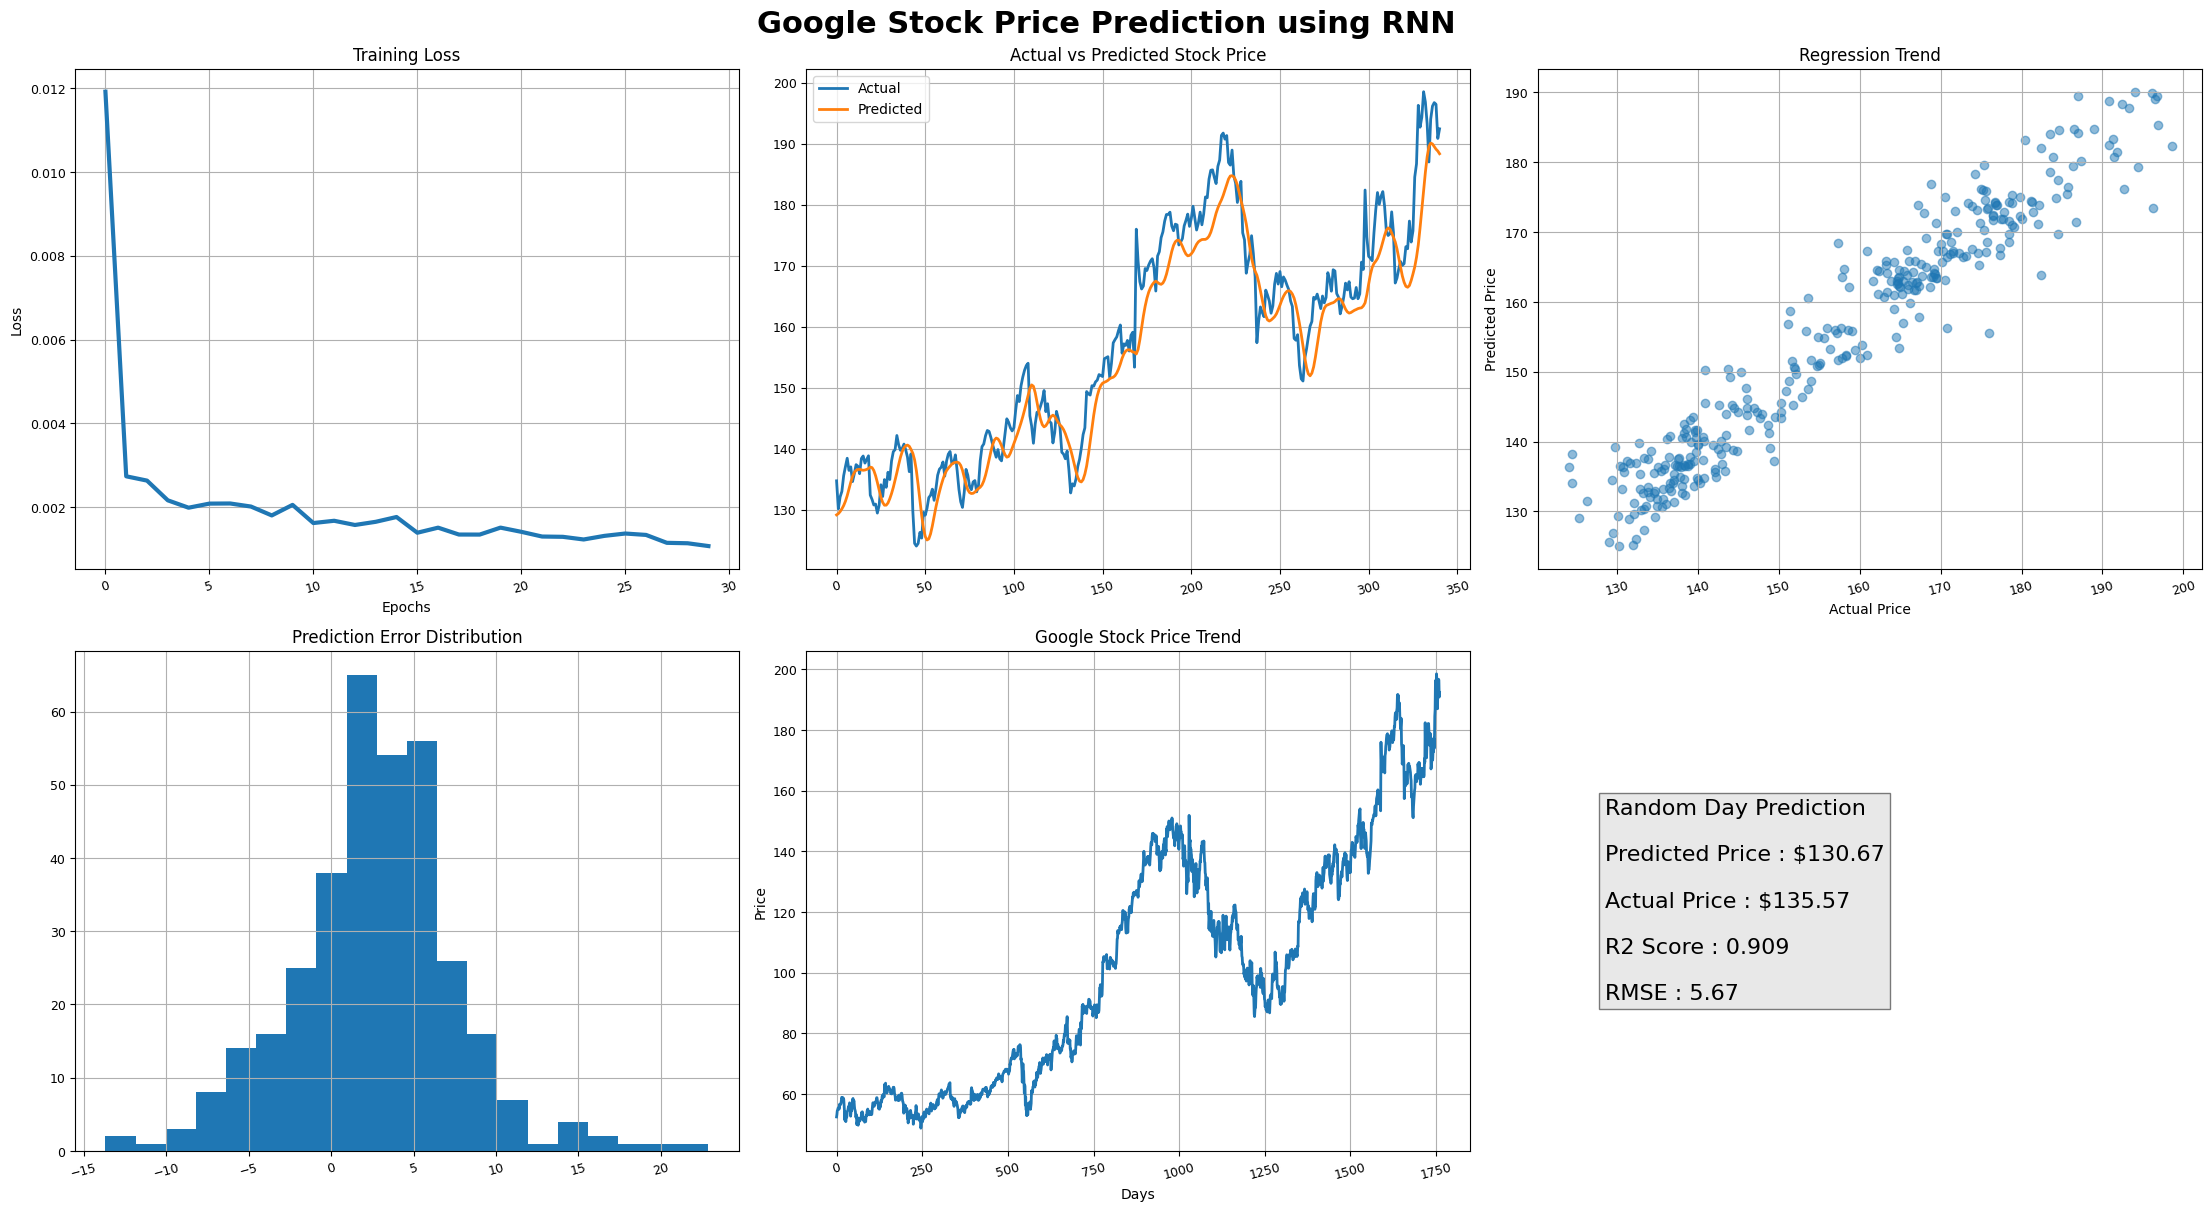


 MODEL SAVED SUCCESSFULLY 

 RNN PROGRAM EXECUTED SUCCESSFULLY 


In [2]:
# =========================================================
# Google Stock Price Prediction using RNN
# FULL FINAL UPDATED SAFE VERSION
# JUPYTER NOTEBOOK VERSION
# =========================================================

# =========================================================
# FEATURES
# =========================================================
#
# ✔ Local CSV Dataset Loading
# ✔ Automatic Stock Column Detection
# ✔ Handles Different CSV Formats
# ✔ Handles Comma Values
# ✔ RNN + LSTM Model
# ✔ Time Series Forecasting
# ✔ Actual vs Predicted Graph
# ✔ Loss Graph
# ✔ Prediction Trend Graph
# ✔ Random Day Prediction
# ✔ All Outputs in ONE Window
# ✔ No Graph Overlap
# ✔ Jupyter Notebook Compatible
#
# =========================================================

# =========================================================
# 1. IMPORT LIBRARIES
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import random

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import (

    mean_squared_error,

    mean_absolute_error,

    r2_score
)

# =========================================================
# 2. LOAD DATASET
# =========================================================

dataset_path = r"C:\Users\sapiyan\DL\RNN\dataset\Stock_Price_Prediction\Google_Stock_Price.csv"

print("\n====================================")
print(" LOADING GOOGLE STOCK DATASET ")
print("====================================")

# ---------------------------------------------------------
# LOAD CSV
# ---------------------------------------------------------

data = pd.read_csv(dataset_path)

print("\n====================================")
print(" DATASET LOADED SUCCESSFULLY ")
print("====================================")

print("\nFirst 5 Rows:\n")

print(data.head())

print("\n====================================")
print(" DATASET COLUMNS ")
print("====================================")

print(data.columns)

# =========================================================
# 3. AUTOMATIC STOCK PRICE COLUMN DETECTION
# =========================================================

possible_columns = [

    'Open',
    'open',

    'Close',
    'close',

    'Adj Close',
    'adj close',

    'Price',
    'price'
]

stock_column = None

for col in possible_columns:

    if col in data.columns:

        stock_column = col
        break

# ---------------------------------------------------------
# CHECK COLUMN
# ---------------------------------------------------------

if stock_column is None:

    print("\nERROR : No Stock Price Column Found!")

    print("\nAvailable Columns:\n")

    print(data.columns)

else:

    print("\nSelected Stock Column :", stock_column)

    # -----------------------------------------------------
    # HANDLE COMMA VALUES
    # -----------------------------------------------------

    dataset = data[stock_column].astype(str)

    dataset = dataset.str.replace(',', '')

    dataset = dataset.astype(float)

    dataset = dataset.values.reshape(-1,1)

    print("\nDataset Shape :", dataset.shape)

    # =====================================================
    # 4. FEATURE SCALING
    # =====================================================

    scaler = MinMaxScaler(
        feature_range=(0,1)
    )

    scaled_data = scaler.fit_transform(dataset)

    print("\nFeature Scaling Completed")

    # =====================================================
    # 5. CREATE TIME SERIES DATA
    # =====================================================

    X = []
    y = []

    TIME_STEPS = 60

    for i in range(TIME_STEPS, len(scaled_data)):

        X.append(
            scaled_data[i-TIME_STEPS:i, 0]
        )

        y.append(
            scaled_data[i,0]
        )

    X = np.array(X)
    y = np.array(y)

    # =====================================================
    # 6. RESHAPE FOR RNN
    # =====================================================

    X = np.reshape(

        X,

        (X.shape[0], X.shape[1], 1)
    )

    print("\n====================================")
    print(" TIME SERIES DATA CREATED ")
    print("====================================")

    print("X Shape :", X.shape)
    print("y Shape :", y.shape)

    # =====================================================
    # 7. TRAIN TEST SPLIT
    # =====================================================

    split = int(0.8 * len(X))

    X_train = X[:split]
    X_test = X[split:]

    y_train = y[:split]
    y_test = y[split:]

    print("\nTraining Shape :", X_train.shape)
    print("Testing Shape  :", X_test.shape)

    # =====================================================
    # 8. BUILD RNN MODEL
    # =====================================================

    model = keras.Sequential([

        # -------------------------------------------------
        # LSTM LAYER 1
        # -------------------------------------------------

        layers.LSTM(

            128,

            return_sequences=True,

            input_shape=(X_train.shape[1],1)
        ),

        layers.Dropout(0.2),

        # -------------------------------------------------
        # LSTM LAYER 2
        # -------------------------------------------------

        layers.LSTM(

            64,

            return_sequences=True
        ),

        layers.Dropout(0.2),

        # -------------------------------------------------
        # LSTM LAYER 3
        # -------------------------------------------------

        layers.LSTM(

            32
        ),

        layers.Dropout(0.2),

        # -------------------------------------------------
        # OUTPUT LAYER
        # -------------------------------------------------

        layers.Dense(1)
    ])

    # =====================================================
    # 9. COMPILE MODEL
    # =====================================================

    model.compile(

        optimizer='adam',

        loss='mean_squared_error'
    )

    print("\n====================================")
    print(" RNN MODEL COMPILED SUCCESSFULLY ")
    print("====================================")

    # =====================================================
    # 10. EARLY STOPPING
    # =====================================================

    early_stop = keras.callbacks.EarlyStopping(

        monitor='loss',

        patience=5,

        restore_best_weights=True
    )

    # =====================================================
    # 11. TRAIN MODEL
    # =====================================================

    print("\n====================================")
    print(" RNN TRAINING STARTED ")
    print("====================================")

    history = model.fit(

        X_train,
        y_train,

        epochs=30,

        batch_size=32,

        callbacks=[early_stop],

        verbose=1
    )

    # =====================================================
    # 12. PREDICTIONS
    # =====================================================

    predictions = model.predict(
        X_test,
        verbose=0
    )

    # =====================================================
    # 13. INVERSE TRANSFORM
    # =====================================================

    predictions = scaler.inverse_transform(
        predictions
    )

    y_test_actual = scaler.inverse_transform(
        y_test.reshape(-1,1)
    )

    # =====================================================
    # 14. PERFORMANCE METRICS
    # =====================================================

    mse = mean_squared_error(

        y_test_actual,

        predictions
    )

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(

        y_test_actual,

        predictions
    )

    r2 = r2_score(

        y_test_actual,

        predictions
    )

    print("\n====================================")
    print(" MODEL EVALUATION ")
    print("====================================")

    print("Mean Squared Error      :", round(mse,2))
    print("Root Mean Squared Error :", round(rmse,2))
    print("Mean Absolute Error     :", round(mae,2))
    print("R2 Score                :", round(r2,3))

    # =====================================================
    # 15. RANDOM DAY PREDICTION
    # =====================================================

    random_index = random.randint(
        0,
        len(predictions)-1
    )

    predicted_price = predictions[random_index][0]

    actual_price = y_test_actual[random_index][0]

    # =====================================================
    # 16. CREATE ALL OUTPUTS TOGETHER
    # =====================================================

    fig, axes = plt.subplots(

        2,
        3,

        figsize=(22, 12),

        constrained_layout=True
    )

    # =====================================================
    # MAIN TITLE
    # =====================================================

    fig.suptitle(

        "Google Stock Price Prediction using RNN",

        fontsize=22,

        fontweight='bold'
    )

    # =====================================================
    # GRAPH 1 : TRAINING LOSS
    # =====================================================

    axes[0,0].plot(

        history.history['loss'],

        linewidth=3
    )

    axes[0,0].set_title(
        "Training Loss"
    )

    axes[0,0].set_xlabel("Epochs")
    axes[0,0].set_ylabel("Loss")

    axes[0,0].grid(True)

    # =====================================================
    # GRAPH 2 : ACTUAL VS PREDICTED
    # =====================================================

    axes[0,1].plot(

        y_test_actual,

        linewidth=2
    )

    axes[0,1].plot(

        predictions,

        linewidth=2
    )

    axes[0,1].set_title(
        "Actual vs Predicted Stock Price"
    )

    axes[0,1].legend([
        "Actual",
        "Predicted"
    ])

    axes[0,1].grid(True)

    # =====================================================
    # GRAPH 3 : REGRESSION TREND
    # =====================================================

    axes[0,2].scatter(

        y_test_actual,

        predictions,

        alpha=0.5
    )

    axes[0,2].set_title(
        "Regression Trend"
    )

    axes[0,2].set_xlabel("Actual Price")
    axes[0,2].set_ylabel("Predicted Price")

    axes[0,2].grid(True)

    # =====================================================
    # GRAPH 4 : ERROR DISTRIBUTION
    # =====================================================

    errors = y_test_actual.flatten() - predictions.flatten()

    axes[1,0].hist(

        errors,

        bins=20
    )

    axes[1,0].set_title(
        "Prediction Error Distribution"
    )

    axes[1,0].grid(True)

    # =====================================================
    # GRAPH 5 : STOCK TREND
    # =====================================================

    axes[1,1].plot(

        dataset,

        linewidth=2
    )

    axes[1,1].set_title(
        "Google Stock Price Trend"
    )

    axes[1,1].set_xlabel("Days")
    axes[1,1].set_ylabel("Price")

    axes[1,1].grid(True)

    # =====================================================
    # GRAPH 6 : RANDOM PREDICTION
    # =====================================================

    axes[1,2].axis("off")

    prediction_text = (

        f"Random Day Prediction\n\n"

        f"Predicted Price : ${predicted_price:.2f}\n\n"

        f"Actual Price : ${actual_price:.2f}\n\n"

        f"R2 Score : {r2:.3f}\n\n"

        f"RMSE : {rmse:.2f}"
    )

    axes[1,2].text(

        0.1,
        0.5,

        prediction_text,

        fontsize=16,

        verticalalignment='center',

        bbox=dict(
            facecolor='lightgray',
            alpha=0.5
        )
    )

    # =====================================================
    # FIX OVERLAPPING
    # =====================================================

    for ax in axes.flat:

        ax.tick_params(

            axis='x',

            rotation=15,

            labelsize=9
        )

        ax.tick_params(

            axis='y',

            labelsize=9
        )

    # =====================================================
    # SHOW EVERYTHING
    # =====================================================

    plt.show()

    # =====================================================
    # 17. SAVE MODEL
    # =====================================================

    model.save(
        "google_stock_rnn_model.h5"
    )

    print("\n====================================")
    print(" MODEL SAVED SUCCESSFULLY ")
    print("====================================")

    # =====================================================
    # 18. PROGRAM FINISHED
    # =====================================================

    print("\n====================================")
    print(" RNN PROGRAM EXECUTED SUCCESSFULLY ")
    print("====================================")